# Detecting Proxy Variables for Protected Classes in HR Data

## Why this matters
Machine learning models in HR (attrition, promotion, performance, pay equity) 
can unintentionally learn **proxy variables** for protected characteristics 
(e.g., gender, race, age), even when those attributes are excluded.

This notebook demonstrates a **practical, auditable approach** to:
- Identify features that strongly correlate with protected classes
- Quantify proxy risk using correlation thresholds
- Support bias mitigation decisions *before* model training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from pathlib import Path

from typing import List

C:\Users\admin\anaconda3\envs\sandbox\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
pip install statsmodel.api

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement statsmodel.api (from versions: none)
ERROR: No matching distribution found for statsmodel.api


In [2]:
# Download latest version
path = kagglehub.dataset_download("rhuebner/human-resources-data-set")
path_2 = Path(path)

files = os.listdir(path)

file = path_2 / files[0]

hr = pd.read_csv(file)

In [3]:
def corr_var(df, var, threshold=0.8, encode_cats=False):
    # Work on a copy so we don’t mutate original data
    df_copy = df.copy()

    # Optionally encode categorical variables
    if encode_cats:
        for col in df_copy.select_dtypes(include=["object", "category"]).columns:
            df_copy[col] = df_copy[col].astype("category").cat.codes

    # Keep only numeric columns
    df_numeric = df_copy.select_dtypes(include=[np.number])

    if var not in df_numeric.columns:
        raise ValueError(f"{var} is not a numeric column or not found in dataframe.")

    # Compute correlation matrix
    corr_matrix = df_numeric.corr()

    # Get absolute correlations with target variable
    corr_series = corr_matrix[var].abs().sort_values(ascending=False)

    # Drop self-correlation
    corr_series = corr_series.drop(labels=[var])

    # Filter by threshold
    high_corr = corr_series[corr_series > threshold]
   

    return corr_series

In [4]:
proxy_df = pd.DataFrame(corr_var(hr, "Absences", threshold=0.7)).reset_index()
proxy_df.columns = ['Factor','Corr']


In [5]:
proxy_df

,Factor,Corr
0,ManagerID,0.127189
1,Termd,0.098274
2,MarriedID,0.096086
3,EmpStatusID,0.091834
4,Salary,0.082382
5,Zip,0.078779
6,EmpSatisfaction,0.075222
7,PositionID,0.071434
8,FromDiversityJobFairID,0.062640
9,DeptID,0.053308


### Interpretation
The following variables show strong correlation with Abscences and may act
as proxy signals in downstream models. These features should be reviewed,
transformed, or excluded depending on business context.

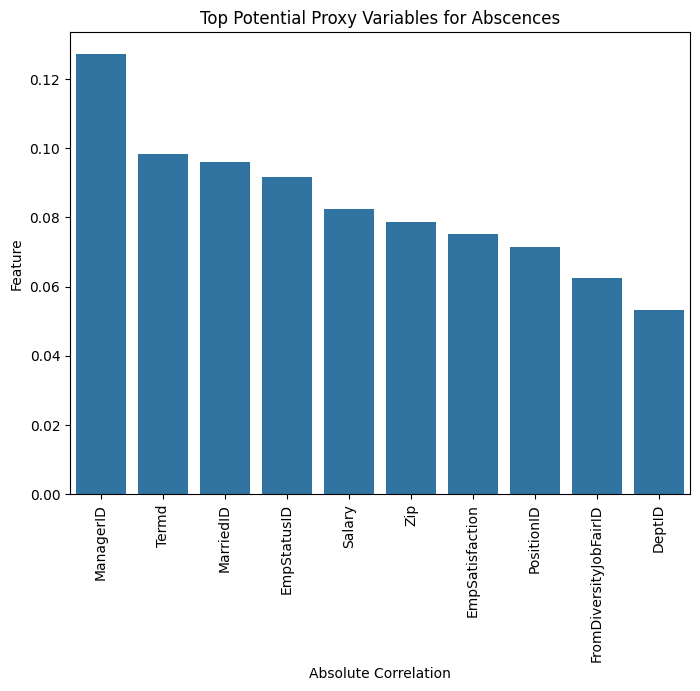

In [6]:
### Chart it Up

plt.figure(figsize=(8, 6))
sns.barplot(
    data= pd.DataFrame(proxy_df).head(10),
    x="Factor",
    y="Corr"
)
plt.title("Top Potential Proxy Variables for Abscences")
plt.xticks(rotation=90)
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.show()

## Limitations & Next Steps

- Correlation does not imply causation
- Non-linear proxy relationships are not captured
- Categorical encoding choices influence correlation strength

### Future Enhancements
- Mutual information for non-linear proxy detection
- SHAP-based proxy analysis in trained models
- Automated proxy reporting for model governance